
# Sea‑Ice Fraction Cleaning Notebook

This notebook ingests the raw **`summary_test.csv`** export from the Uummannaq Sentinel‑2 tile catalogue, fills missing daily values and writes
**`summary_test_cleaned.csv`**.

## Method (quick recap)

| Step | Description |
|------|-------------|
| 1 | Compute **daily mean ice‑fraction** (solid + light) across all tiles. |
| 2 | Derive a multi‑year **climatology**: mean fraction for each day‑of‑year (DOY). |
| 3 | For each individual year:<br/>• linear‑interpolate gaps ≤ **14 days**<br/>• remaining vacancies are filled with the climatology value.<br/>Outside the solar‑illumination window (DOY 45‑180) raw values are left unchanged. |
| 4 | Apply a **7‑day centred running mean** to damp residual noise. |
| 5 | Save to `summary_test_cleaned.csv` (columns: raw, filled, smoothed). |

Feel free to tweak the constants in **Cell 2** if you have different scientific preferences.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW_FILE   = Path('summary_test.csv')          # path to the raw file
OUT_FILE   = Path('summary_test_cleaned.csv')  # output
SUN_START  = 45        # first DOY considered (15 Feb)
SUN_END    = 180       # last  DOY considered (29 Jun)
SHORT_GAP  = 14        # maximum gap length (days) to interp
WINDOW     = 7         # running‑mean window length (days, centred)

df = pd.read_csv(RAW_FILE, low_memory=False)
print(f'Loaded {len(df):,} raw tile records')


Loaded 1,552 raw tile records


In [2]:
# --- 1️⃣  daily mean fraction -----------------------------------------
df['date'] = pd.to_datetime(df['timestamp'], format='%Y%m%dT%H%M%S', utc=True)
df['year'] = df['date'].dt.year
df['doy']  = df['date'].dt.dayofyear

# fraction per tile
df['frac'] = df[['solid_pct','light_pct']].sum(axis=1)

daily = (df.groupby('date', as_index=False)
           .agg(year=('year', 'first'),
                doy =('doy',  'first'),
                frac=('frac', 'mean')))

# --- NEW: turn every timestamp into the same _day_ stamp -----------------
daily['date'] = pd.to_datetime(daily['date']).dt.normalize()   # <-- key line
# -------------------------------------------------------------------------

daily = (daily.set_index('date')      # now they line up with midnight
               .asfreq('D')           # inserts missing days → NaNs
               .reset_index())

daily['year'] = daily['date'].dt.year       # rebuild for the new rows
daily['doy']  = daily['date'].dt.dayofyear


print(f'Daily series spans {daily.year.min()}‑{daily.year.max()}  with {len(daily)} rows')


Daily series spans 2017‑2025  with 3047 rows


In [3]:
# --- 2️⃣  DOY climatology ---------------------------------------------
clim = (daily.groupby('doy')['frac']
              .mean()
              .rename('clim_frac')
              .reset_index())
daily = daily.merge(clim, on='doy')


In [4]:
# --- 3️⃣  gap‑filling --------------------------------------------------
def fill_year(group):
    g = group.set_index('doy').sort_index()
    window_mask = (g.index >= SUN_START) & (g.index <= SUN_END)

    frac = g['frac'].astype(float).copy()

    # (a) linear interpolate small gaps
    frac = frac.interpolate(limit=SHORT_GAP, limit_direction='both')

    # (b) long gaps -> climatology
    frac = frac.fillna(g['clim_frac'])

    # (c) outside illumination window keep original (could remain NaN)
    frac.loc[~window_mask] = g['frac'].loc[~window_mask]

    g['frac_filled'] = frac
    return g.reset_index()

daily = (daily.groupby('year', group_keys=False)
               .apply(fill_year))


/var/folders/2l/6514_hd91tv5448lmq79vpbw0000gn/T/ipykernel_4823/3008852709.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fill_year))


In [5]:
# --- 4️⃣  running mean (triangular, 13 d effective) --------------------------
ROLL = WINDOW  # keep WINDOW = 7 above; two passes → triangular kernel

daily['frac_smooth'] = (
    daily.groupby('year')['frac_filled']
         .transform(lambda s: s.rolling(window=ROLL, center=True, min_periods=1).mean()
                                 .rolling(window=ROLL, center=True, min_periods=1).mean())
)

# discard values outside the illumination window (Option A)
outside = (daily['doy'] < SUN_START) | (daily['doy'] > SUN_END)
daily.loc[outside, 'frac_smooth'] = np.nan


In [6]:
# --- 5️⃣  export -------------------------------------------------------
cols = ['date','year','doy','frac','frac_filled','frac_smooth']
daily[cols].to_csv(OUT_FILE, index=False, float_format='%.6f')
print('✅ Wrote', OUT_FILE.resolve())


✅ Wrote /Users/lukaskreibig/Documents/Dokumente Cloud/climate-dashboard/uummannaq-ice/ice-final/summary_test_cleaned.csv


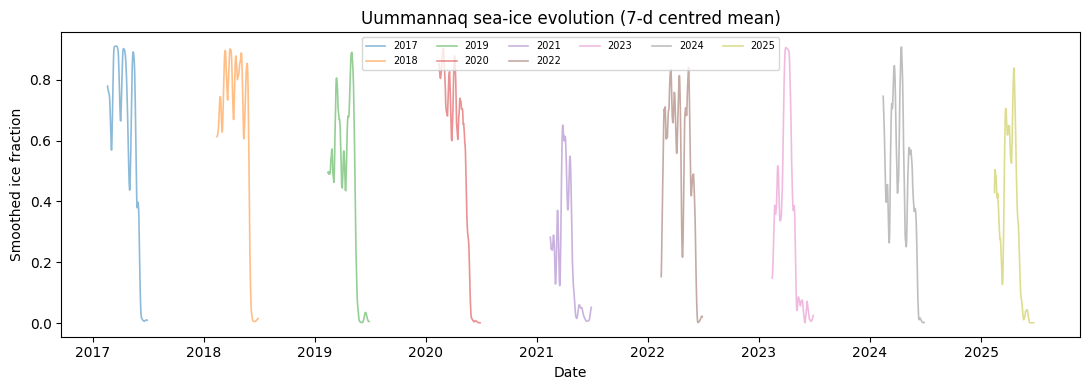

In [7]:
# --- 6️⃣  quick sanity visual -----------------------------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,4))
for yr, g in daily.groupby('year'):
    ax.plot(g['date'], g['frac_smooth'], lw=1.2, alpha=0.5, label=yr)
ax.set_ylabel('Smoothed ice fraction')
ax.set_xlabel('Date')
ax.set_title('Uummannaq sea‑ice evolution (7‑d centred mean)')
ax.legend(ncol=6, fontsize=7)
plt.tight_layout()
plt.show()
